# CA6003: Hotel Booking Demand — A Data-Centric Investigation

**Course:** CA6003 Best Practices in Data Governance, Preparation and Analytics  
**Dataset:** Hotel Booking Demand  
**Prediction Target:** `IsCanceled` (Cancelled / Not Cancelled)  
**Model:** Logistic Regression  

> **Data Source:** [Add dataset URL, authors, licence, access date, and citation.]

## Project Overview

This notebook presents a data-centric investigation of the Hotel Booking Demand dataset, with `IsCanceled` as the binary prediction target. The analysis focuses on data quality, integrity, representation, potential bias, and potentially misleading relationships before applying machine learning.

The workflow begins with systematic data profiling and exploratory data analysis (EDA) to identify missingness, inconsistencies, anomalies, outliers, and other integrity concerns. These findings are then used to guide evidence-based data cleaning, validation, transformation, and feature engineering.

To evaluate the impact of data preparation, the same Logistic Regression approach is applied to both minimally processed and systematically prepared data. The model is used as an analytical tool rather than the primary objective: changes in predictive performance, robustness, and interpretability are examined to understand how data preparation decisions influence model behaviour.

# 1. Introduction

## Purpose

This project investigates how systematic data preparation affects the reliability and behaviour of a hotel booking cancellation model. The primary focus is on identifying and addressing data quality, integrity, bias, and potentially misleading relationships rather than maximising predictive accuracy.

## Method

The analysis follows a data-centric workflow: systematic profiling and data-quality assessment, integrity and bias investigation, exploratory data analysis (EDA), evidence-based data preparation, and controlled model evaluation. A Logistic Regression model is trained to predict `IsCanceled`, with the same modelling approach applied to minimally processed and systematically prepared data.

## Evaluation Approach

The comparison focuses not only on predictive metrics, but also on how individual preparation decisions influence model behaviour and the credibility of the resulting evaluation. All conclusions are based on the empirical evidence generated within this notebook.

# 2. Dataset Loading and Description

The configuration uses relative paths and explicitly expects the two supplied files. Each row receives provenance fields before concatenation. Structure, sample records, types, and target values are inspected to detect schema or loading problems before analysis.

In [1]:
from pathlib import Path
from IPython.display import display
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, RocCurveDisplay)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_SEED = 6003
np.random.seed(RANDOM_SEED)
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 15)
sns.set_theme(style='whitegrid', context='notebook', palette='colorblind')
plt.rcParams.update({
    'figure.figsize': (9, 5), 'figure.dpi': 110, 'savefig.dpi': 300,
    'axes.titlesize': 14, 'axes.labelsize': 11, 'xtick.labelsize': 10,
    'ytick.labelsize': 10, 'legend.fontsize': 9, 'axes.spines.top': False,
    'axes.spines.right': False
})
warnings.filterwarnings('ignore', category=FutureWarning)

DATA_DIR = Path('dataset')
DATA_FILES = [DATA_DIR / 'H1.csv', DATA_DIR / 'H2.csv']
TARGET = 'IsCanceled'
TEST_SIZE = 0.20
FIGURE_DIR = Path('figures')
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

def save_and_show(filename):
    path = FIGURE_DIR / filename
    plt.tight_layout()
    plt.savefig(path, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved figure: {path}')

missing_files = [str(path) for path in DATA_FILES if not path.exists()]
if missing_files:
    raise FileNotFoundError(f'Missing expected data file(s): {missing_files}')


In [2]:
frames = []
for path in DATA_FILES:
    frame = pd.read_csv(path)
    frame['HotelSourceFile'] = path.name
    frame['HotelType'] = {'H1.csv': 'H1', 'H2.csv': 'H2'}.get(path.name, path.stem)
    frames.append(frame)

schemas = {path.name: tuple(frame.columns[:-2]) for path, frame in zip(DATA_FILES, frames)}
if len(set(schemas.values())) != 1:
    raise ValueError(f'Input schemas differ: {schemas}')

raw_df = pd.concat(frames, ignore_index=True, sort=False)
if TARGET not in raw_df.columns:
    raise KeyError(f'Target column {TARGET!r} was not found.')

numeric_columns = raw_df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = raw_df.select_dtypes(exclude=np.number).columns.tolist()
overview = pd.DataFrame({'Value': {
    'Rows': len(raw_df), 'Columns': raw_df.shape[1],
    'Numerical features': len(numeric_columns) - int(TARGET in numeric_columns),
    'Categorical features': len(categorical_columns), 'Target': TARGET,
    'H1 rows': (raw_df['HotelSourceFile'] == 'H1.csv').sum(),
    'H2 rows': (raw_df['HotelSourceFile'] == 'H2.csv').sum()
}})
display(overview)
display(raw_df.head(5))


,Value
Rows,119390
Columns,33
Numerical features,17
Categorical features,15
Target,IsCanceled
H1 rows,40060
H2 rows,79330


,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,...,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate,HotelSourceFile,HotelType
0,0,342,2015,July,27,1,0,0,2,0.0,...,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01,H1.csv,H1
1,0,737,2015,July,27,1,0,0,2,0.0,...,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01,H1.csv,H1
2,0,7,2015,July,27,1,0,1,1,0.0,...,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02,H1.csv,H1
3,0,13,2015,July,27,1,0,1,1,0.0,...,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02,H1.csv,H1
4,0,14,2015,July,27,1,0,2,2,0.0,...,NULL,0,Transient,98.0,0,1,Check-Out,2015-07-03,H1.csv,H1


**Execution check:** Confirm that both files load with matching schemas and that `IsCanceled` is binary. Record any parsing issue before analysis; no silent correction is permitted.

# 3. Systematic Data Profiling

## 3.1 Dataset Structure
The following inventory separates numerical and categorical fields and reports target counts and proportions.

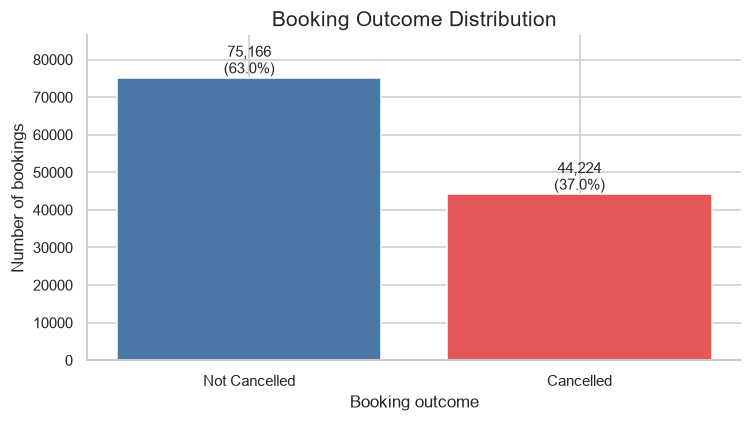

Saved figure: figures\01_target_distribution.png


In [3]:
target_profile = pd.concat([
    raw_df[TARGET].value_counts(dropna=False).rename('count'),
    raw_df[TARGET].value_counts(dropna=False, normalize=True).mul(100).rename('percent')
], axis=1)
target_profile.index = target_profile.index.map({0: 'Not Cancelled', 1: 'Cancelled'})
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(target_profile.index, target_profile['count'], color=['#4C78A8', '#E45756'])
for bar, (_, row) in zip(bars, target_profile.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{int(row['count']):,}\n({row['percent']:.1f}%)",
            ha='center', va='bottom', fontsize=10)
ax.set(title='Booking Outcome Distribution', xlabel='Booking outcome', ylabel='Number of bookings')
ax.margins(y=0.15)
save_and_show('01_target_distribution.png')


## 3.2 Missing Values
Python missing values are distinguished from empty/whitespace strings and textual markers. Marker counts are evidence for investigation, not automatic proof of missingness.

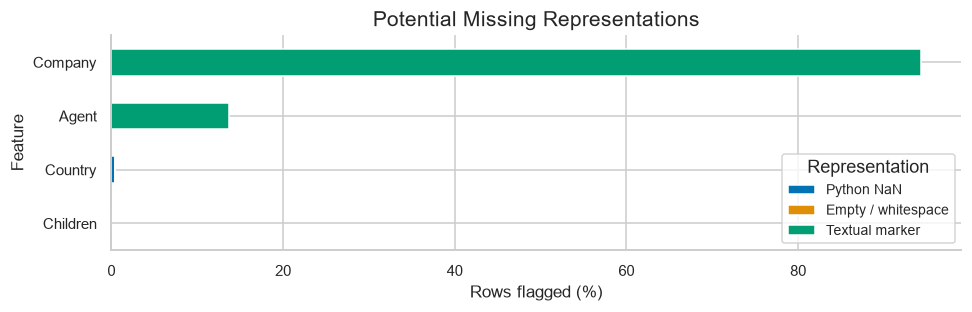

Saved figure: figures\02_missingness.png


,Observed marker
Agent,NULL
Company,NULL


In [4]:
TEXTUAL_MISSING_MARKERS = {'null', 'na', 'n/a', 'unknown'}
python_missing = raw_df.isna().sum()
empty_or_whitespace = pd.Series(0, index=raw_df.columns, dtype='int64')
textual_marker_count = pd.Series(0, index=raw_df.columns, dtype='int64')
textual_marker_examples = {}

for column in categorical_columns:
    text = raw_df[column].dropna().astype(str)
    stripped = text.str.strip()
    empty_or_whitespace[column] = stripped.eq('').sum()
    marker_mask = stripped.str.casefold().isin(TEXTUAL_MISSING_MARKERS)
    textual_marker_count[column] = marker_mask.sum()
    textual_marker_examples[column] = sorted(stripped[marker_mask].unique().tolist())

missing_profile = pd.DataFrame({
    'python_missing_count': python_missing,
    'python_missing_percent': python_missing.div(len(raw_df)).mul(100),
    'empty_or_whitespace_count': empty_or_whitespace,
    'textual_marker_count': textual_marker_count
})
missing_profile['combined_flag_count'] = missing_profile[[
    'python_missing_count', 'empty_or_whitespace_count', 'textual_marker_count'
]].sum(axis=1)
missing_profile['combined_flag_percent'] = missing_profile['combined_flag_count'].div(len(raw_df)).mul(100)
plot_missing = missing_profile.query('combined_flag_count > 0').sort_values('combined_flag_percent')
if not plot_missing.empty:
    missing_plot = plot_missing[['python_missing_percent']].copy()
    missing_plot['Empty / whitespace'] = plot_missing['empty_or_whitespace_count'].div(len(raw_df)).mul(100)
    missing_plot['Textual marker'] = plot_missing['textual_marker_count'].div(len(raw_df)).mul(100)
    missing_plot = missing_plot.rename(columns={'python_missing_percent': 'Python NaN'})
    ax = missing_plot.plot.barh(stacked=True, figsize=(9, max(3, .45 * len(missing_plot))))
    ax.set(title='Potential Missing Representations', xlabel='Rows flagged (%)', ylabel='Feature')
    ax.legend(title='Representation', loc='lower right')
    save_and_show('02_missingness.png')
    marker_detail = pd.Series({k: ', '.join(v) for k, v in textual_marker_examples.items() if v}, name='Observed marker')
    if not marker_detail.empty:
        display(marker_detail.to_frame().head(10))
else:
    print('No potential missing values were flagged by the defined checks.')


### Interpretation
**TODO after execution:** Identify material missingness and whether it is concentrated in particular fields. Treat textual markers as missing only when field semantics and documentation support that decision; “absent”, “unknown”, and “not applicable” are not automatically equivalent.

## 3.3 Duplicate Records
Exact equality is checked both with and without the added provenance fields. Because no unique booking identifier is supplied, identical feature rows are not automatically confirmed duplicate bookings and will not be deleted.

In [5]:
source_columns = ['HotelSourceFile', 'HotelType']
original_columns = [c for c in raw_df.columns if c not in source_columns]
exact_with_source = raw_df.duplicated(keep=False)
identical_feature_rows = raw_df.duplicated(subset=original_columns, keep=False)
duplicate_summary = pd.DataFrame({'Value': {
    'Total rows': len(raw_df),
    'Identical-feature rows': identical_feature_rows.sum(),
    'Identical-feature rows (%)': identical_feature_rows.mean() * 100
}})
display(duplicate_summary)


,Value
Total rows,119390.000000
Identical-feature rows,40165.000000
Identical-feature rows (%),33.641846


### Interpretation
**TODO after execution:** Report the proportion of identical-feature rows. These are not confirmed duplicate bookings because no unique booking identifier is available, so they remain unless independent provenance supports deletion.

## 3.4 Categorical Consistency
Raw uniqueness, case-folded uniqueness, whitespace, and frequencies reveal inconsistent representations and rare or suspicious categories.

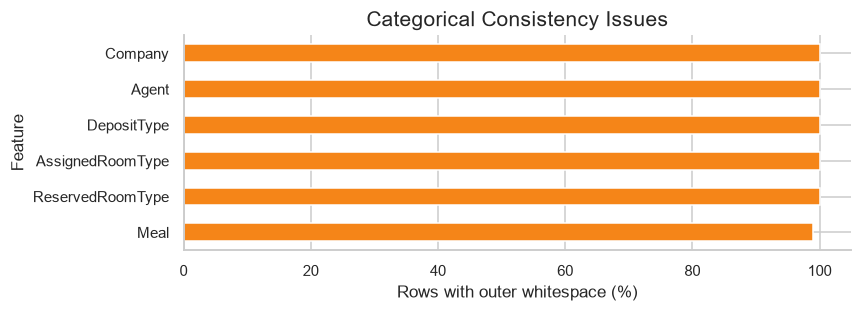

Saved figure: figures\03_categorical_consistency.png


In [6]:
categorical_consistency_rows = []
for column in categorical_columns:
    values = raw_df[column].dropna().astype(str)
    stripped = values.str.strip()
    categorical_consistency_rows.append({
        'column': column,
        'raw_unique': values.nunique(),
        'trimmed_casefold_unique': stripped.str.casefold().nunique(),
        'values_with_outer_whitespace': values.ne(stripped).sum(),
        'rarest_frequency': values.value_counts().min() if len(values) else np.nan
    })
categorical_consistency = pd.DataFrame(categorical_consistency_rows).set_index('column')
categorical_consistency['affected_rows'] = categorical_consistency['values_with_outer_whitespace']
categorical_consistency['affected_percent'] = categorical_consistency['affected_rows'].div(len(raw_df)).mul(100)
consistency_issues = categorical_consistency.query(
    'affected_rows > 0 or raw_unique != trimmed_casefold_unique'
).sort_values('affected_percent')
if not consistency_issues.empty:
    ax = consistency_issues['affected_percent'].plot.barh(color='#F58518', figsize=(8, max(3, .45 * len(consistency_issues))))
    ax.set(title='Categorical Consistency Issues', xlabel='Rows with outer whitespace (%)', ylabel='Feature')
    save_and_show('03_categorical_consistency.png')
else:
    print('No whitespace or case-only categorical inconsistencies were detected.')


## 3.5 Numerical Summary
Mean, median, dispersion, quantiles, extrema, skewness, and IQR flags are descriptive signals. An IQR flag is not a deletion rule.

In [7]:
numerical_features = [c for c in numeric_columns if c != TARGET]
numerical_summary = raw_df[numerical_features].describe(percentiles=[.01, .25, .5, .75, .99]).T
numerical_summary['median'] = raw_df[numerical_features].median()
numerical_summary['skewness'] = raw_df[numerical_features].skew(numeric_only=True)
q1 = raw_df[numerical_features].quantile(.25)
q3 = raw_df[numerical_features].quantile(.75)
iqr = q3 - q1
iqr_flag = raw_df[numerical_features].lt(q1 - 1.5 * iqr) | raw_df[numerical_features].gt(q3 + 1.5 * iqr)
numerical_summary['iqr_flag_count'] = iqr_flag.sum()
numerical_summary['iqr_flag_percent'] = iqr_flag.mean().mul(100)
profile_features = [c for c in ['LeadTime', 'ADR', 'PreviousCancellations',
                                  'BookingChanges', 'TotalOfSpecialRequests'] if c in numerical_summary.index]
profile_view = numerical_summary.loc[profile_features, ['median', 'skewness', 'min', 'max',
                                                         'iqr_flag_count', 'iqr_flag_percent']]
display(profile_view.round(3))


,median,skewness,min,max,iqr_flag_count,iqr_flag_percent
LeadTime,69.000,1.347,0.00,737.0,3005,2.517
ADR,94.575,10.530,-6.38,5400.0,3793,3.177
PreviousCancellations,0.000,24.458,0.00,26.0,6484,5.431
BookingChanges,0.000,6.000,0.00,21.0,18076,15.140
TotalOfSpecialRequests,0.000,1.349,0.00,5.0,2877,2.410


### Interpretation
**TODO after execution:** Distinguish impossible values from plausible extremes and coding conventions. Statistical extremeness alone is insufficient grounds for deletion; preparation should follow field meaning and documented evidence.

# 4. Data Quality and Integrity Investigation

Each issue should be documented as **Observation → Investigation → Possible explanation → Decision → Justification**. The code below creates targeted integrity indicators; it does not automatically remove observations.

In [8]:
integrity_checks = {}
if {'Adults', 'Children', 'Babies'}.issubset(raw_df.columns):
    total_guests = raw_df[['Adults', 'Children', 'Babies']].sum(axis=1, min_count=1)
    integrity_checks['non_positive_total_guests'] = total_guests.le(0)
if {'StaysInWeekendNights', 'StaysInWeekNights'}.issubset(raw_df.columns):
    total_nights = raw_df[['StaysInWeekendNights', 'StaysInWeekNights']].sum(axis=1, min_count=1)
    integrity_checks['negative_total_nights'] = total_nights.lt(0)
if 'ADR' in raw_df.columns:
    integrity_checks['negative_ADR'] = raw_df['ADR'].lt(0)
if 'LeadTime' in raw_df.columns:
    integrity_checks['negative_lead_time'] = raw_df['LeadTime'].lt(0)
if {'ArrivalDateYear', 'ArrivalDateMonth', 'ArrivalDateDayOfMonth'}.issubset(raw_df.columns):
    arrival_text = (raw_df['ArrivalDateYear'].astype('Int64').astype(str) + '-' +
                    raw_df['ArrivalDateMonth'].astype(str) + '-' +
                    raw_df['ArrivalDateDayOfMonth'].astype('Int64').astype(str))
    parsed_arrival = pd.to_datetime(arrival_text, errors='coerce')
    integrity_checks['invalid_arrival_date_components'] = parsed_arrival.isna()
if {'ReservedRoomType', 'AssignedRoomType'}.issubset(raw_df.columns):
    integrity_checks['assigned_room_differs_from_reserved'] = raw_df['ReservedRoomType'].ne(raw_df['AssignedRoomType'])

integrity_summary = pd.DataFrame({
    name: {'flagged_count': mask.sum(), 'flagged_percent': mask.mean() * 100}
    for name, mask in integrity_checks.items()
}).T.sort_values('flagged_count', ascending=False)
integrity_issues = integrity_summary.query('flagged_count > 0').copy()
integrity_issues.index = integrity_issues.index.str.replace('_', ' ').str.title()
display(integrity_issues.rename(columns={'flagged_count': 'Affected rows',
                                          'flagged_percent': 'Percentage'}).round(3))


,Affected rows,Percentage
Assigned Room Differs From Reserved,14917.0,12.494
Non Positive Total Guests,180.0,0.151
Negative Adr,1.0,0.001


### Quality decision log (complete after execution)

| Issue | Observation | Investigation | Possible explanation | Decision | Justification |
|---|---|---|---|---|---|
| Missingness | TODO | TODO | TODO | TODO | TODO |
| Categorical inconsistency | TODO | TODO | TODO | TODO | TODO |
| Extreme or impossible values | TODO | TODO | TODO | TODO | TODO |
| Identical feature rows | TODO | TODO | TODO | Retain unless confirmed | No unique booking identifier |
| Other integrity issue | TODO | TODO | TODO | TODO | TODO |

# 5. Target and Potential Data Leakage Analysis

Data leakage occurs when a predictor contains information unavailable at the intended prediction time or directly encodes the outcome. Predictive correlation alone does not establish legitimacy: a useful predictor must also be available when the prediction is made. `ReservationStatus` and `ReservationStatusDate` are investigated because their names suggest post-outcome information; they are not assumed safe merely because they predict well.

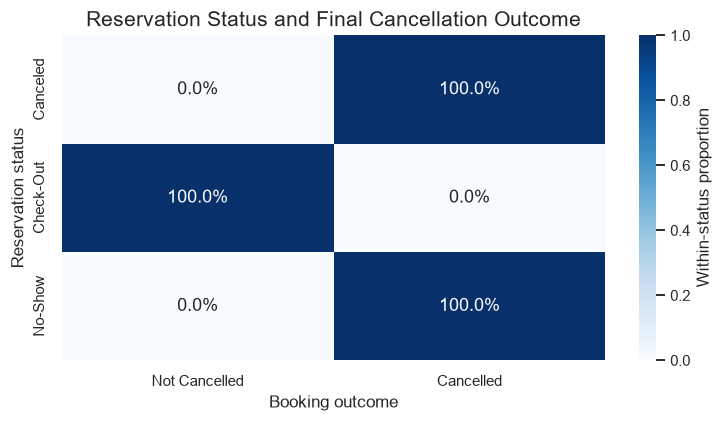

Saved figure: figures\07_leakage_reservation_status.png
ReservationStatusDate parse failures: 0. Its timing must be assessed against the intended prediction point.


In [9]:
if 'ReservationStatus' in raw_df.columns:
    status_target = pd.crosstab(raw_df['ReservationStatus'], raw_df[TARGET], normalize='index')
    status_target = status_target.rename(columns={0: 'Not Cancelled', 1: 'Cancelled'})
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.heatmap(status_target, annot=True, fmt='.1%', cmap='Blues', vmin=0, vmax=1,
                cbar_kws={'label': 'Within-status proportion'}, ax=ax)
    ax.set(title='Reservation Status and Final Cancellation Outcome',
           xlabel='Booking outcome', ylabel='Reservation status')
    save_and_show('07_leakage_reservation_status.png')

if 'ReservationStatusDate' in raw_df.columns:
    status_date = pd.to_datetime(raw_df['ReservationStatusDate'], errors='coerce')
    print(f'ReservationStatusDate parse failures: {status_date.isna().sum():,}. '
          'Its timing must be assessed against the intended prediction point.')


### Interpretation
**TODO after execution:** Quantify how closely `ReservationStatus` aligns with the final outcome shown above. Its status and date describe information available after the booking outcome, so their predictive power is not legitimate for pre-outcome cancellation prediction; both are excluded from systematic modelling. The minimal baseline retains them only to expose the consequence of untreated leakage.

# 6. Bias Analysis

Representation, outcome rates, and missingness are compared across observed groups. A difference is an observed association, not by itself evidence of unfair discrimination. Fairness claims require the deployment context, protected-attribute definitions, causal reasoning, and knowledge of collection mechanisms that may be absent here.

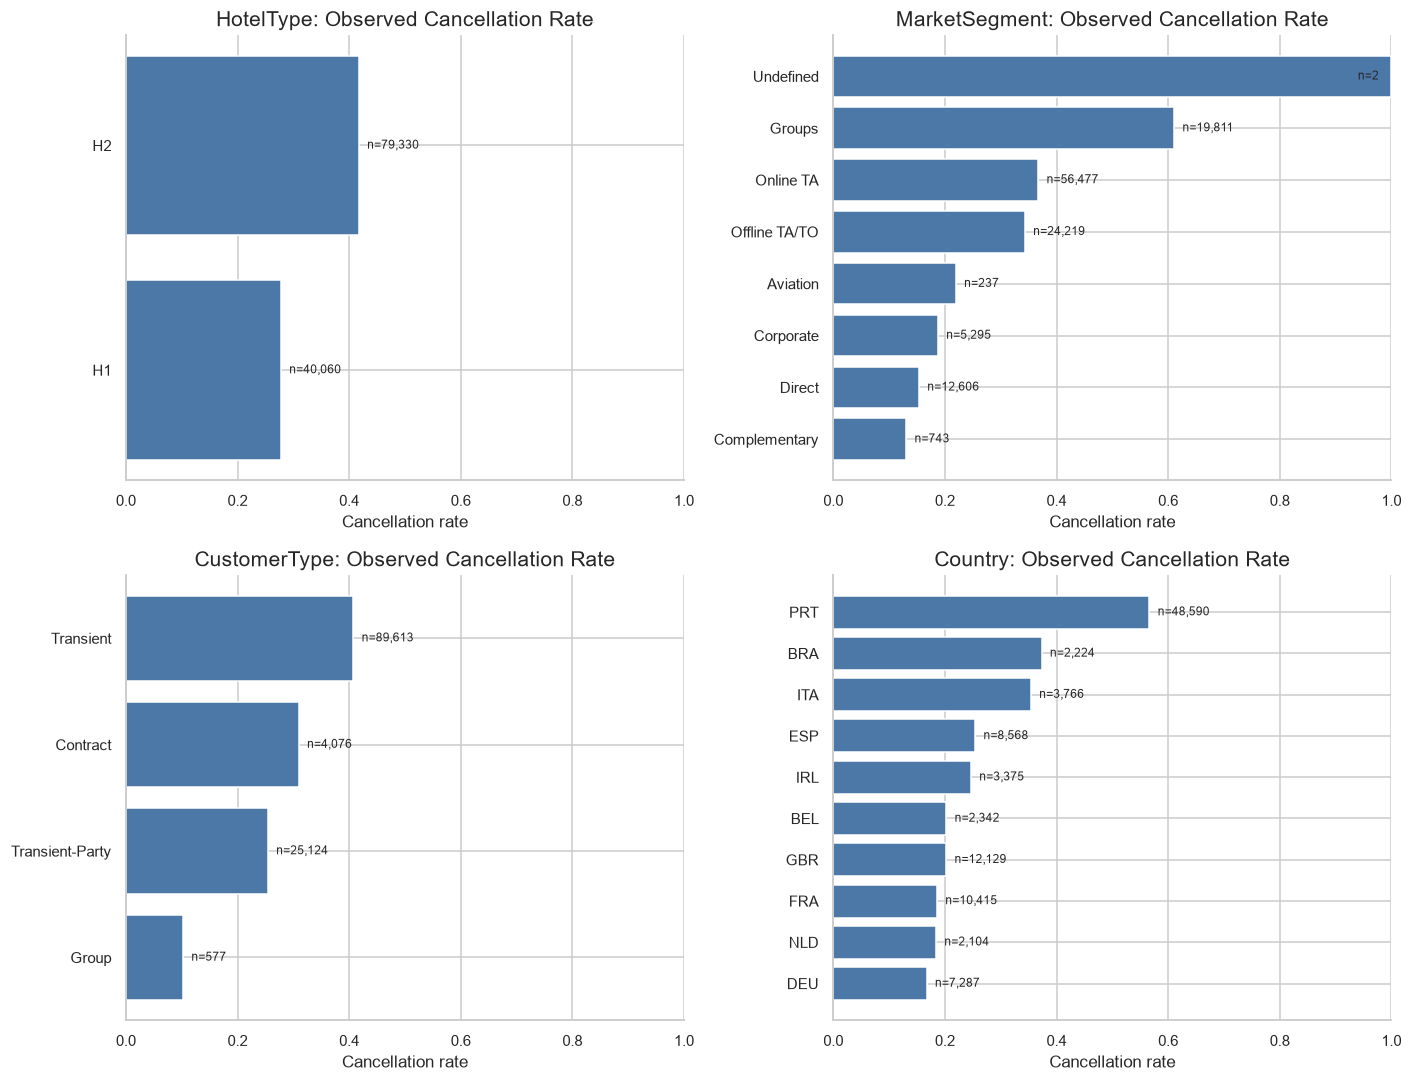

Saved figure: figures\08_bias_group_comparison.png
Group-specific missingness matrices were computed for audit; inspect the stored `group_missingness_summary` object if a plotted group difference requires follow-up.


In [10]:
candidate_group_columns = [
    'HotelType', 'Country', 'MarketSegment', 'DistributionChannel',
    'CustomerType', 'DepositType', 'IsRepeatedGuest'
]
available_group_columns = [c for c in candidate_group_columns if c in raw_df.columns]

bias_plot_groups = [c for c in ['HotelType', 'MarketSegment', 'CustomerType', 'Country']
                    if c in available_group_columns]
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, group in zip(axes.flat, bias_plot_groups):
    limit = 10 if group == 'Country' else 12
    summary = (raw_df.groupby(group, dropna=False)[TARGET].agg(n='size', cancellation_rate='mean')
               .sort_values('n', ascending=False).head(limit).sort_values('cancellation_rate'))
    bars = ax.barh(summary.index.astype(str), summary['cancellation_rate'], color='#4C78A8')
    for bar, n in zip(bars, summary['n']):
        ax.text(min(bar.get_width() + .015, .94), bar.get_y() + bar.get_height()/2,
                f'n={n:,}', va='center', fontsize=8)
    ax.set(title=f'{group}: Observed Cancellation Rate', xlabel='Cancellation rate', ylabel='')
    ax.set_xlim(0, 1)
for ax in axes.flat[len(bias_plot_groups):]:
    ax.set_visible(False)
save_and_show('08_bias_group_comparison.png')

missing_indicators = raw_df.isna().add_suffix('__missing')
group_missingness_summary = {}
for group in bias_plot_groups:
    group_missingness = pd.concat([raw_df[[group]], missing_indicators], axis=1).groupby(group, dropna=False).mean()
    material_columns = group_missingness.columns[group_missingness.max().gt(0)]
    if len(material_columns):
        group_missingness_summary[group] = group_missingness[material_columns]
print('Group-specific missingness matrices were computed for audit; inspect the stored '
      '`group_missingness_summary` object if a plotted group difference requires follow-up.')


### Interpretation
**TODO after execution:** Identify substantial differences only where sample sizes are adequate, and note under-represented groups. Observed subgroup differences do not establish discrimination; they may reflect sampling, market mix, or unmeasured context.

# 7. Exploratory Data Analysis (EDA)

EDA is organised around cancellation-relevant questions rather than exhaustive plotting. Selected numerical fields are examined for distribution, skewness, and group differences; selected categories are examined for representation and cancellation rate.

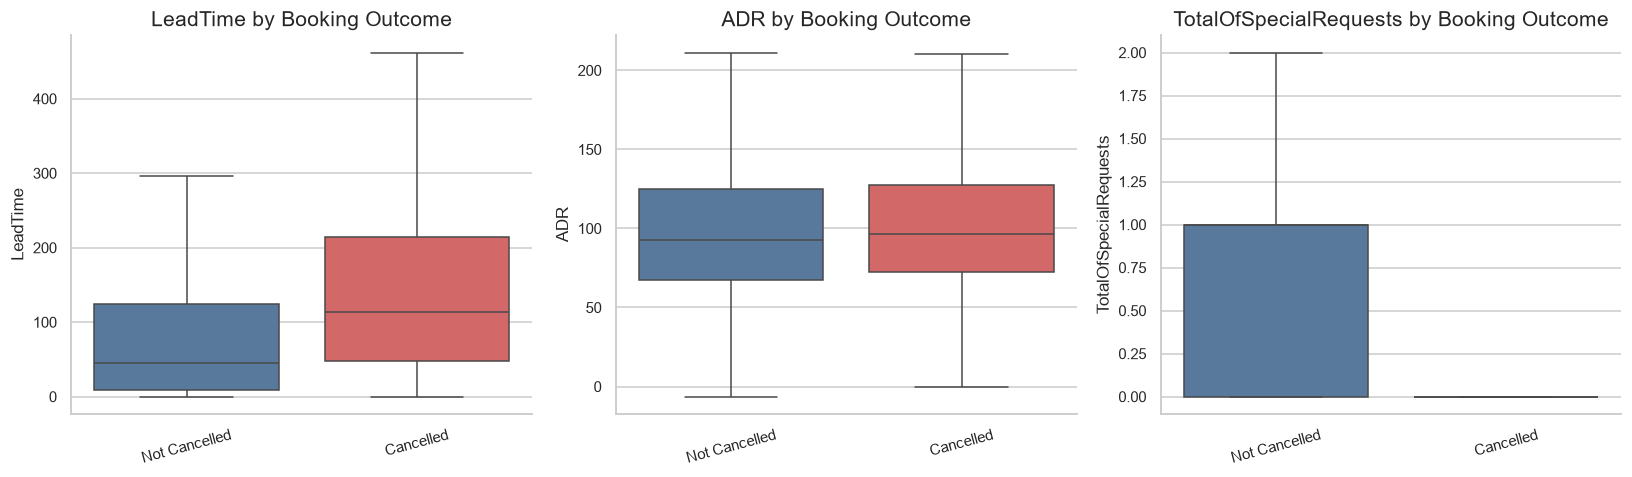

Saved figure: figures\04_numerical_eda.png


In [11]:
eda_numeric = [c for c in ['LeadTime', 'ADR', 'TotalOfSpecialRequests'] if c in raw_df.columns]
fig, axes = plt.subplots(1, len(eda_numeric), figsize=(15, 4.5))
axes = np.atleast_1d(axes)
outcome_labels = raw_df[TARGET].map({0: 'Not Cancelled', 1: 'Cancelled'})
for ax, column in zip(axes, eda_numeric):
    plot_frame = raw_df[[column]].assign(Outcome=outcome_labels)
    sns.boxplot(data=plot_frame, x='Outcome', y=column, showfliers=False,
                palette=['#4C78A8', '#E45756'], ax=ax)
    ax.set(title=f'{column} by Booking Outcome', xlabel='', ylabel=column)
    ax.tick_params(axis='x', rotation=15)
save_and_show('04_numerical_eda.png')


### Interpretation
**TODO after execution:** Summarise the two or three substantive distribution differences and their overlap. Boxplot fliers are hidden only for readability and remain in the data; associations must not be interpreted causally.

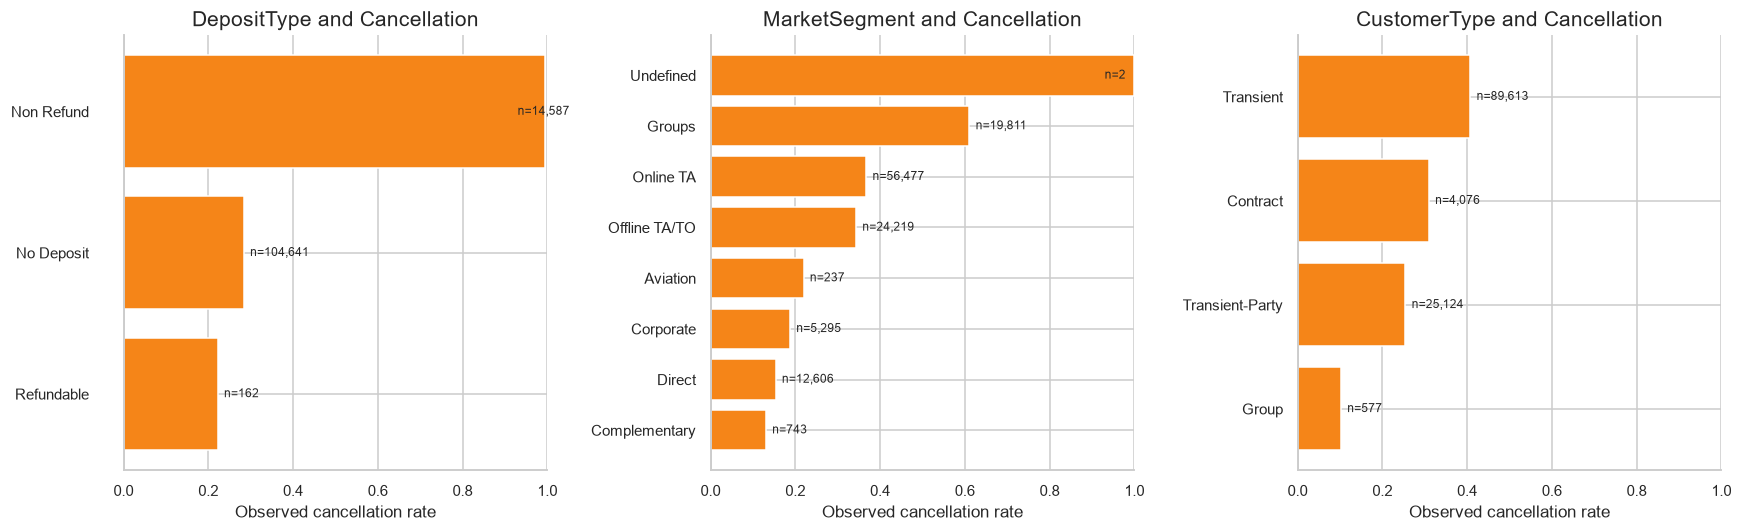

Saved figure: figures\05_categorical_eda.png


In [12]:
eda_categorical = [c for c in ['DepositType', 'MarketSegment', 'CustomerType'] if c in raw_df.columns]
fig, axes = plt.subplots(1, len(eda_categorical), figsize=(16, 5))
axes = np.atleast_1d(axes)
for ax, column in zip(axes, eda_categorical):
    grouped = raw_df.groupby(column, dropna=False)[TARGET].agg(n='size', cancellation_rate='mean')
    grouped = grouped.sort_values('n', ascending=False).head(12).sort_values('cancellation_rate')
    bars = ax.barh(grouped.index.astype(str), grouped['cancellation_rate'], color='#F58518')
    for bar, n in zip(bars, grouped['n']):
        ax.text(min(bar.get_width() + .015, .93), bar.get_y() + bar.get_height()/2,
                f'n={n:,}', va='center', fontsize=8)
    ax.set(title=f'{column} and Cancellation', xlabel='Observed cancellation rate', ylabel='')
    ax.set_xlim(0, 1)
save_and_show('05_categorical_eda.png')


### Interpretation
**TODO after execution:** Report the strongest well-supported category differences, using the annotated sample sizes to avoid over-interpreting sparse groups. These are predictive associations, not evidence that category membership causes cancellation.

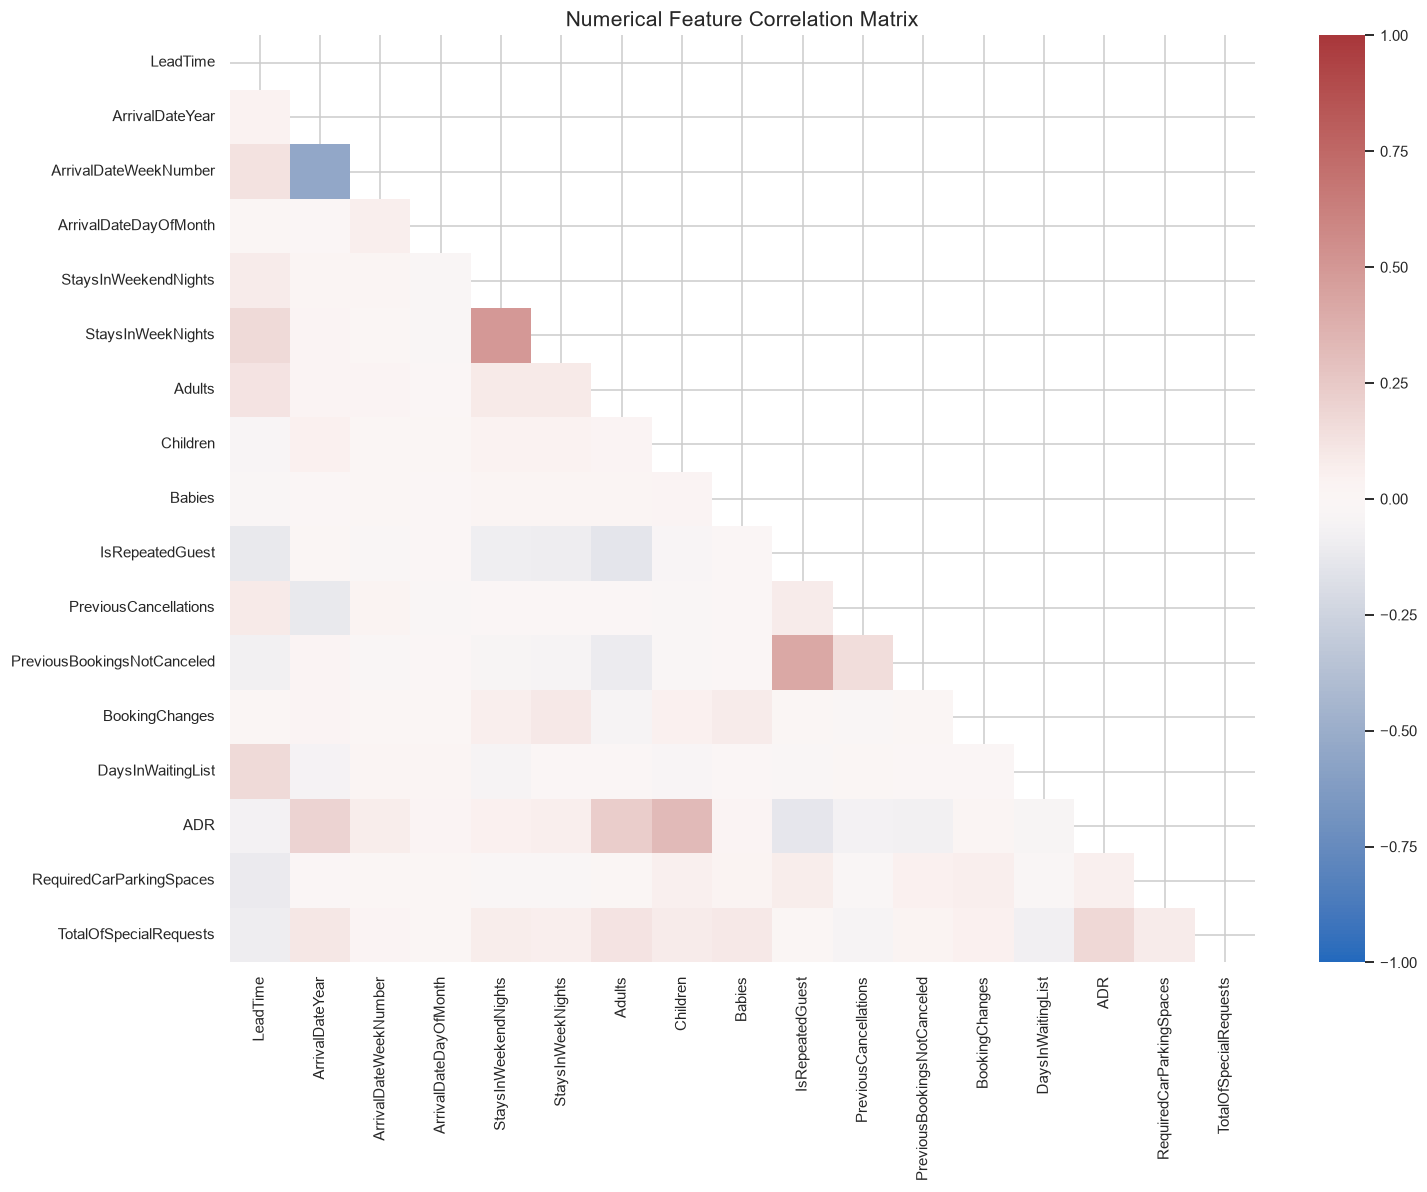

Saved figure: figures\06_correlation_heatmap.png


,,correlation,abs_correlation


In [13]:
corr_columns = [c for c in numerical_features if raw_df[c].nunique(dropna=True) > 1]
correlation_matrix = raw_df[corr_columns].corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(14, 11))
sns.heatmap(correlation_matrix, mask=mask, cmap='vlag', center=0, vmin=-1, vmax=1)
plt.title('Numerical Feature Correlation Matrix')
save_and_show('06_correlation_heatmap.png')

upper = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
high_corr_pairs = (upper.stack().rename('correlation').to_frame()
                   .assign(abs_correlation=lambda x: x['correlation'].abs())
                   .query('abs_correlation >= 0.70')
                   .sort_values('abs_correlation', ascending=False))
display(high_corr_pairs.head(10).round(3))


### Interpretation
**TODO after execution:** Discuss only the strongest relationships and whether they encode overlapping concepts. Pairwise correlation is an incomplete multicollinearity diagnostic and does not, by itself, justify feature removal.

# 8. Analytical Fallacies and Misleading Relationships

## Correlation versus causation
Associations may reflect selection, seasonality, pricing policy, market mix, or other confounders. This observational dataset cannot by itself establish causal effects.

## Simpson's paradox investigation
A candidate relationship is screened at aggregate level and within plausible subgroups. A paradox requires a genuine direction reversal (or a clearly justified disappearance/attenuation), adequate subgroup size, and careful handling of continuous variables. No paradox will be claimed automatically.

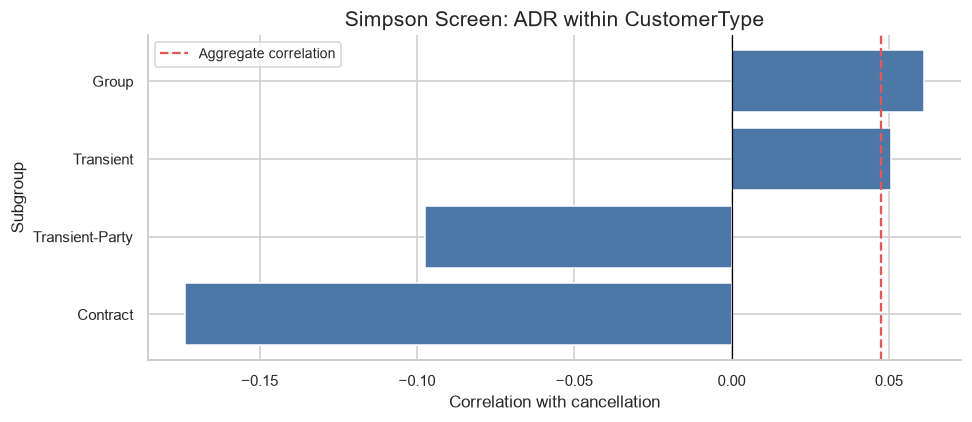

Saved figure: figures\09_simpson_candidate.png


In [14]:
simpson_numeric_candidates = [c for c in ['LeadTime', 'ADR', 'TotalOfSpecialRequests',
                                           'BookingChanges'] if c in raw_df.columns]
simpson_group_candidates = [c for c in ['HotelType', 'MarketSegment', 'CustomerType',
                                         'DepositType'] if c in raw_df.columns]
simpson_rows = []
for feature in simpson_numeric_candidates:
    aggregate = raw_df[[feature, TARGET]].dropna().corr().iloc[0, 1]
    for group in simpson_group_candidates:
        for level, subset in raw_df.groupby(group, dropna=False):
            complete = subset[[feature, TARGET]].dropna()
            within = complete.corr().iloc[0, 1] if len(complete) >= 30 and complete[feature].nunique() > 1 else np.nan
            simpson_rows.append({
                'feature': feature, 'group_variable': group, 'group_level': level,
                'n_complete': len(complete), 'aggregate_correlation': aggregate,
                'within_group_correlation': within,
                'direction_reversal': (np.sign(aggregate) != np.sign(within)) if pd.notna(within) and aggregate != 0 else False
            })
simpson_screen = pd.DataFrame(simpson_rows)
simpson_screen['abs_within_correlation'] = simpson_screen['within_group_correlation'].abs()
credible_screen = simpson_screen.query(
    'direction_reversal and n_complete >= 500 and abs_within_correlation >= 0.05'
).copy()
if not credible_screen.empty:
    candidate_key = (credible_screen.assign(change=lambda d: (d['within_group_correlation'] -
                                                              d['aggregate_correlation']).abs())
                     .sort_values('change', ascending=False).iloc[0][['feature', 'group_variable']])
    selected = simpson_screen[(simpson_screen['feature'] == candidate_key['feature']) &
                              (simpson_screen['group_variable'] == candidate_key['group_variable'])]
    selected = selected.query('n_complete >= 500').sort_values('within_group_correlation')
    fig, ax = plt.subplots(figsize=(9, max(4, .4 * len(selected))))
    ax.barh(selected['group_level'].astype(str), selected['within_group_correlation'], color='#4C78A8')
    ax.axvline(selected['aggregate_correlation'].iloc[0], color='#E45756', linestyle='--',
               label='Aggregate correlation')
    ax.axvline(0, color='black', linewidth=.8)
    ax.set(title=f"Simpson Screen: {candidate_key['feature']} within {candidate_key['group_variable']}",
           xlabel='Correlation with cancellation', ylabel='Subgroup')
    ax.legend()
    save_and_show('09_simpson_candidate.png')
else:
    print("No convincing Simpson's paradox candidate met the pre-specified screen.")


### Interpretation
**TODO after execution:** If a candidate is plotted, assess its magnitude, subgroup sizes, and substantive plausibility before calling it Simpson's paradox. Otherwise state that no convincing paradox was established under the tested groupings; confounding, subgroup composition, and leakage can still make aggregate relationships misleading.

# 9. Non-obvious Finding Investigation

## Investigation story: outcome leakage

**Observation → investigation:** `ReservationStatus` and `ReservationStatusDate` appear to describe the realised booking outcome. The normalized heatmap in Section 5 tests alignment between status and `IsCanceled`, while the ablation isolates the behavioural change when these fields are removed.

**Evidence → interpretation (TODO after execution):** Insert the observed status/outcome proportions and the metric change at the leakage-removal stage. Consider whether the relationship could be legitimate at the intended prediction time; verify timing against source documentation.

**Modelling implication:** If the executed evidence confirms post-outcome availability, high predictive power is leakage rather than genuine foresight. Excluding these fields makes the systematic estimate more credible even if headline performance decreases.

# 10. Evidence-based Data Preparation

The conservative systematic plan performs deterministic text normalisation, repairs only clearly impossible negative values in non-negative measures by setting them missing for training-fold imputation, engineers transparent totals/indicators, and excludes post-outcome leakage fields. It does not delete identical rows or automatically cap statistically extreme observations.

### Major preparation decisions

| Issue | Evidence to confirm after execution | Preparation decision | Reason |
|---|---|---|---|
| Post-outcome fields | Section 5 heatmap and field timing | Exclude status and status date | Prevent outcome leakage |
| Categorical formatting | Section 3.4 consistency check | Trim outer whitespace | Consolidate equivalent representations |
| Clearly impossible negatives | Section 4 integrity summary | Set to missing, then training-fold impute | Avoid treating impossible codes as measurements |
| Identical-feature rows | Section 3.3 summary; no booking ID | Retain unless independently confirmed | Similarity does not prove duplicate bookings |
| Extreme values | Numerical profile and field semantics | No automatic capping/deletion | Extremeness alone is insufficient evidence |

Textual markers are recoded only after field-level verification. Add supported column/marker pairs to the configuration below; the default remains empty.

In [15]:
# Update only when the executed profiling and source documentation support recoding.
VERIFIED_MISSING_MARKERS_BY_COLUMN = {
    # Example format only: 'ColumnName': {'verified marker'}
}
LEAKAGE_COLUMNS = [c for c in ['ReservationStatus', 'ReservationStatusDate'] if c in raw_df.columns]
NON_MODELLING_PROVENANCE_COLUMNS = [c for c in ['HotelSourceFile'] if c in raw_df.columns]
NON_NEGATIVE_COLUMNS = [c for c in [
    'LeadTime', 'StaysInWeekendNights', 'StaysInWeekNights', 'Adults', 'Children',
    'Babies', 'PreviousCancellations', 'PreviousBookingsNotCanceled', 'BookingChanges',
    'DaysInWaitingList', 'RequiredCarParkingSpaces', 'TotalOfSpecialRequests'
] if c in raw_df.columns]

def normalise_categorical_text(frame):
    result = frame.copy()
    for column in result.select_dtypes(include=['object', 'string']).columns:
        normalised = result[column].astype('string').str.strip()
        markers = {str(x).strip().casefold() for x in VERIFIED_MISSING_MARKERS_BY_COLUMN.get(column, set())}
        if markers:
            normalised = normalised.mask(normalised.str.casefold().isin(markers))
        # sklearn's SimpleImputer cannot reliably compare pandas pd.NA values.
        # Use object dtype with np.nan at the pandas/sklearn boundary instead.
        result[column] = normalised.astype(object).where(normalised.notna(), np.nan)
    return result

def add_transparent_features(frame):
    result = frame.copy()
    if {'StaysInWeekendNights', 'StaysInWeekNights'}.issubset(result.columns):
        result['TotalNights'] = result['StaysInWeekendNights'] + result['StaysInWeekNights']
    if {'Adults', 'Children', 'Babies'}.issubset(result.columns):
        result['TotalGuests'] = result[['Adults', 'Children', 'Babies']].sum(axis=1, min_count=1)
        result['PartyHasChildren'] = ((result['Children'].fillna(0) + result['Babies'].fillna(0)) > 0).astype(int)
    if {'ReservedRoomType', 'AssignedRoomType'}.issubset(result.columns):
        result['RoomChanged'] = result['ReservedRoomType'].ne(result['AssignedRoomType']).astype(int)
    return result

def repair_verified_impossible_values(frame):
    result = frame.copy()
    for column in NON_NEGATIVE_COLUMNS:
        result.loc[result[column] < 0, column] = np.nan
    return result

def prepare_stage_features(frame, clean_categories=False, repair_invalid=False,
                           remove_leakage=False, engineer_features=False):
    result = frame.copy()
    if clean_categories:
        result = normalise_categorical_text(result)
    if repair_invalid:
        result = repair_verified_impossible_values(result)
    if engineer_features:
        result = add_transparent_features(result)
    if remove_leakage:
        # File provenance is retained for audit/EDA but is not an operational predictor.
        result = result.drop(columns=LEAKAGE_COLUMNS + NON_MODELLING_PROVENANCE_COLUMNS, errors='ignore')
    return result


# 11. Minimal vs Systematic Preparation

Dataset A receives only type-compatible imputation and one-hot encoding/scaling required by logistic regression. Dataset B applies justified deterministic preparation before a training-fitted preprocessing pipeline. The split indices, observations, estimator, random seed, and metrics remain identical. Imputers, encoder, and scaler learn from training data only.

In [16]:
if raw_df[TARGET].isna().any():
    raise ValueError('Target contains missing values; investigate before modelling.')
if raw_df[TARGET].nunique() != 2:
    raise ValueError('Target is not binary; investigate before modelling.')

X_raw = raw_df.drop(columns=[TARGET])
y = raw_df[TARGET].astype(int)
train_index, test_index = train_test_split(
    raw_df.index, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)

X_minimal = prepare_stage_features(X_raw)
X_systematic = prepare_stage_features(
    X_raw, clean_categories=True, repair_invalid=True,
    remove_leakage=True, engineer_features=True
)

assert X_minimal.index.equals(X_systematic.index)
assert set(train_index).isdisjoint(set(test_index))
print('Minimal shape:', X_minimal.shape)
print('Systematic shape:', X_systematic.shape)
print('Systematic-only columns:', sorted(set(X_systematic) - set(X_minimal)))
print('Columns removed systematically:', sorted(set(X_minimal) - set(X_systematic)))


Minimal shape: (119390, 32)
Systematic shape: (119390, 33)
Systematic-only columns: ['PartyHasChildren', 'RoomChanged', 'TotalGuests', 'TotalNights']
Columns removed systematically: ['HotelSourceFile', 'ReservationStatus', 'ReservationStatusDate']


**Execution check:** Verify that both datasets use identical row indices and split membership. Disable any preparation step not supported by the executed evidence and document the reason.

# 12. Basic Interpretable Machine Learning Model

Both experiments use `sklearn.linear_model.LogisticRegression` with no tuning. Numeric median imputation, scaling, categorical most-frequent imputation, and one-hot encoding are fitted inside each training pipeline to prevent test-set leakage.

In [17]:
def build_logistic_pipeline(X):
    numeric = X.select_dtypes(include=np.number).columns.tolist()
    categorical = [c for c in X.columns if c not in numeric]
    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])
    preprocessor = ColumnTransformer([
        ('numeric', numeric_pipeline, numeric),
        ('categorical', categorical_pipeline, categorical)
    ], remainder='drop')
    model = LogisticRegression(max_iter=2000, random_state=RANDOM_SEED)
    return Pipeline([('preprocessor', preprocessor), ('model', model)])

def fit_and_evaluate(X, label):
    pipeline = build_logistic_pipeline(X)
    pipeline.fit(X.loc[train_index], y.loc[train_index])
    predictions = pipeline.predict(X.loc[test_index])
    probabilities = pipeline.predict_proba(X.loc[test_index])[:, 1]
    metrics = {
        'Accuracy': accuracy_score(y.loc[test_index], predictions),
        'Precision': precision_score(y.loc[test_index], predictions, zero_division=0),
        'Recall': recall_score(y.loc[test_index], predictions, zero_division=0),
        'F1': f1_score(y.loc[test_index], predictions, zero_division=0),
        'ROC-AUC': roc_auc_score(y.loc[test_index], probabilities)
    }
    return {'label': label, 'pipeline': pipeline, 'predictions': predictions,
            'probabilities': probabilities, 'metrics': metrics}


# 13. Model Evaluation

Accuracy, precision, recall, F1, confusion matrices, and ROC-AUC are computed from held-out predictions. ROC-AUC is included to complement threshold-dependent metrics; its relevance should be discussed in light of class balance. Higher accuracy is not automatically better data practice, especially when leakage or subgroup instability is involved.

,Minimal,Systematically Prepared
Metric,,
Accuracy,1.0,0.839434
Precision,1.0,0.817272
Recall,1.0,0.729678
F1,1.0,0.770995
ROC-AUC,1.0,0.918240


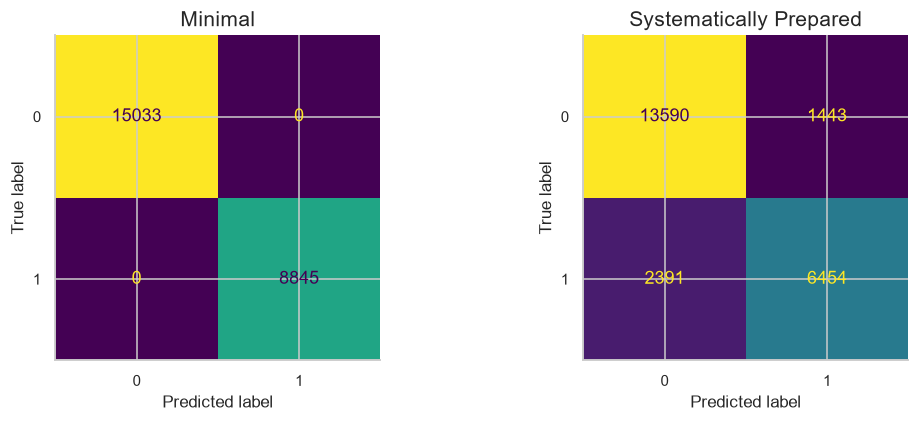

Saved figure: figures\10_confusion_matrices.png


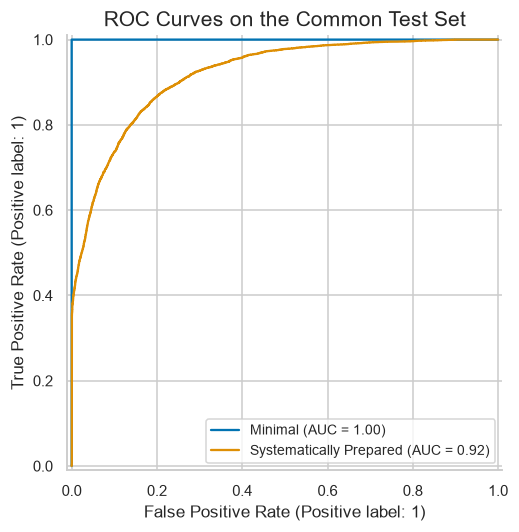

Saved figure: figures\11_roc_comparison.png


In [18]:
# Make this cell robust to X_systematic created by an earlier in-memory version
# of the cleaning function, where categorical missing values may still be pd.NA.
def make_sklearn_compatible(frame):
    result = frame.copy()
    categorical = result.select_dtypes(include=['object', 'string']).columns
    for column in categorical:
        values = result[column].astype(object)
        result[column] = values.mask(pd.isna(values), np.nan)
    return result

minimal_result = fit_and_evaluate(make_sklearn_compatible(X_minimal), 'Minimal')
systematic_result = fit_and_evaluate(make_sklearn_compatible(X_systematic), 'Systematically Prepared')
model_results = [minimal_result, systematic_result]
comparison_table = pd.DataFrame({r['label']: r['metrics'] for r in model_results})
comparison_table.index.name = 'Metric'
display(comparison_table)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, result in zip(axes, model_results):
    ConfusionMatrixDisplay.from_predictions(y.loc[test_index], result['predictions'], ax=ax, colorbar=False)
    ax.set_title(result['label'])
save_and_show('10_confusion_matrices.png')

fig, ax = plt.subplots(figsize=(7, 5))
for result in model_results:
    RocCurveDisplay.from_predictions(y.loc[test_index], result['probabilities'], name=result['label'], ax=ax)
ax.set_title('ROC Curves on the Common Test Set')
save_and_show('11_roc_comparison.png')


### Interpretation
**TODO after execution:** Compare error types and discrimination on the common test set. Higher predictive accuracy is not automatically better data practice: if the minimal model benefits from outcome leakage, lower systematic metrics represent a more credible estimate of genuine pre-outcome performance, not simply a worse model.

# 14. Impact of Individual Preparation Steps

A staged ablation adds only applicable decisions while preserving the split, estimator, and metrics. The missing-value stage is represented by verified marker recoding; if its configuration remains empty, report that the stage is not applicable rather than claiming an effect.

,Accuracy,Precision,Recall,F1,ROC-AUC
Preparation Stage,,,,,
Stage 0: Minimal,1.000000,1.000000,1.000000,1.000000,1.000000
Stage 1: + categorical cleaning / verified markers,1.000000,1.000000,1.000000,1.000000,1.000000
Stage 2: + verified impossible-value repair,1.000000,1.000000,1.000000,1.000000,1.000000
Stage 3: + leakage removal,0.836628,0.815065,0.723007,0.766281,0.915811
Stage 4: + transparent feature engineering,0.839434,0.817272,0.729678,0.770995,0.918240


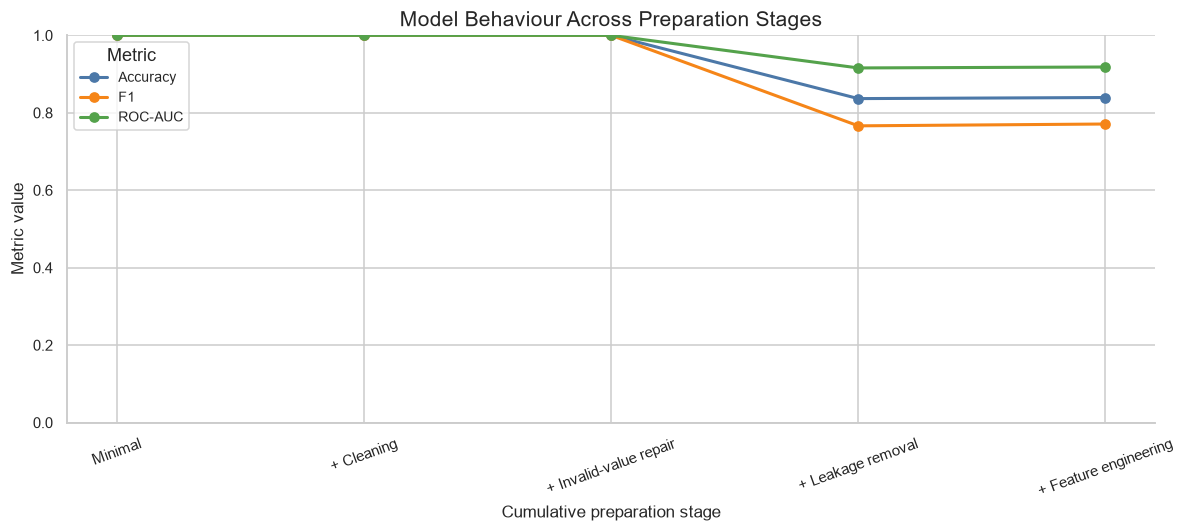

Saved figure: figures\12_ablation_stages.png


In [19]:
stage_definitions = [
    ('Stage 0: Minimal', dict()),
    ('Stage 1: + categorical cleaning / verified markers', dict(clean_categories=True)),
    ('Stage 2: + verified impossible-value repair', dict(clean_categories=True, repair_invalid=True)),
    ('Stage 3: + leakage removal', dict(clean_categories=True, repair_invalid=True, remove_leakage=True)),
    ('Stage 4: + transparent feature engineering', dict(clean_categories=True, repair_invalid=True,
                                                            remove_leakage=True, engineer_features=True)),
]
stage_results = []
stage_artifacts = {}
for stage_name, options in stage_definitions:
    stage_X = prepare_stage_features(X_raw, **options)
    result = fit_and_evaluate(stage_X, stage_name)
    stage_results.append({'Preparation Stage': stage_name, **result['metrics']})
    stage_artifacts[stage_name] = {'X': stage_X, **result}

stage_comparison = pd.DataFrame(stage_results).set_index('Preparation Stage')
display(stage_comparison)
plot_metrics = ['Accuracy', 'F1', 'ROC-AUC']
stage_labels = ['Minimal', '+ Cleaning', '+ Invalid-value repair',
                '+ Leakage removal', '+ Feature engineering']
fig, ax = plt.subplots(figsize=(11, 5))
for metric, color in zip(plot_metrics, ['#4C78A8', '#F58518', '#54A24B']):
    ax.plot(stage_labels, stage_comparison[metric], marker='o', linewidth=2,
            markersize=6, label=metric, color=color)
ax.set(title='Model Behaviour Across Preparation Stages',
       xlabel='Cumulative preparation stage', ylabel='Metric value', ylim=(0, 1))
ax.tick_params(axis='x', rotation=20)
ax.legend(title='Metric')
save_and_show('12_ablation_stages.png')


### Interpretation
**TODO after execution:** Identify the largest adjacent-stage change and connect it to the corresponding preparation decision. A decline after leakage removal improves validity despite reducing headline performance; report stages with no material effect or no applicable evidence.

# 15. Robustness / Fairness / Interpretability Discussion

The following cells evaluate systematic-model performance by sufficiently represented observed groups and recover one-hot/scaled feature names for coefficients. Group metrics are diagnostic, not proof of fairness. Coefficients describe conditional model associations on the transformed scale and are not causal effects.

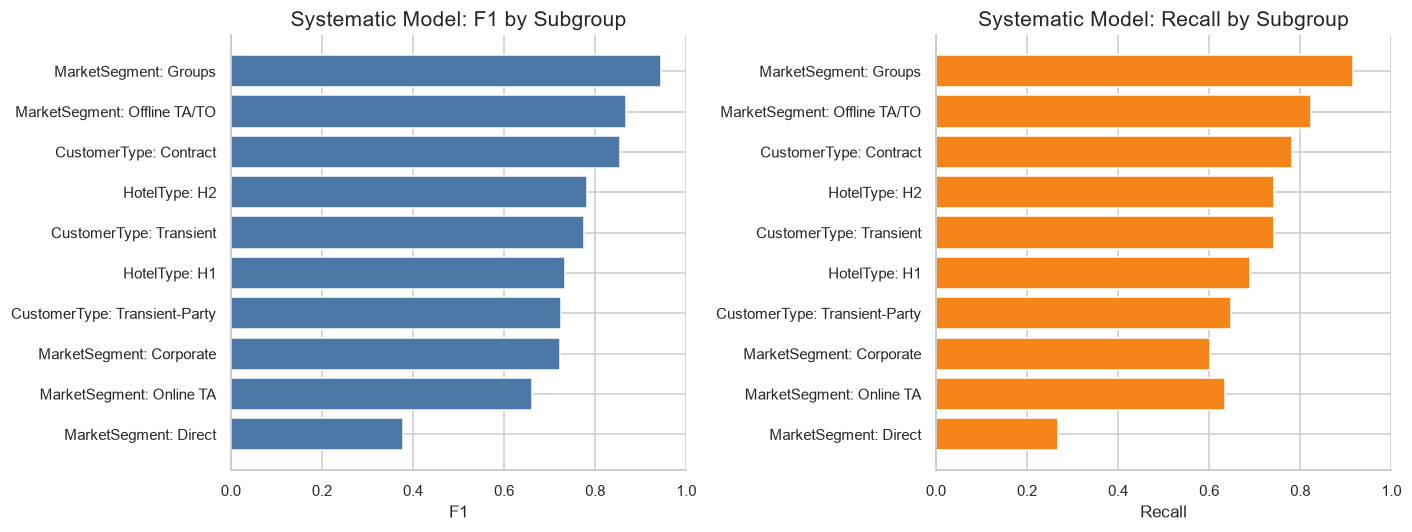

Saved figure: figures\13_subgroup_robustness.png
Only test-set subgroups with at least 200 observations are plotted.


In [20]:
MIN_SUBGROUP_TEST_SIZE = 200
subgroup_rows = []
test_metadata = raw_df.loc[test_index]
for group in available_group_columns:
    for level, positions in test_metadata.groupby(group, dropna=False).groups.items():
        positional_mask = test_index.isin(positions)
        n = positional_mask.sum()
        y_group = y.loc[test_index][positional_mask]
        pred_group = systematic_result['predictions'][positional_mask]
        prob_group = systematic_result['probabilities'][positional_mask]
        subgroup_rows.append({
            'group': group, 'level': level, 'n_test': n,
            'positive_rate': y_group.mean() if n else np.nan,
            'Accuracy': accuracy_score(y_group, pred_group) if n else np.nan,
            'Precision': precision_score(y_group, pred_group, zero_division=0) if n else np.nan,
            'Recall': recall_score(y_group, pred_group, zero_division=0) if n else np.nan,
            'F1': f1_score(y_group, pred_group, zero_division=0) if n else np.nan,
            'ROC-AUC': roc_auc_score(y_group, prob_group) if n >= MIN_SUBGROUP_TEST_SIZE and y_group.nunique() == 2 else np.nan
        })
subgroup_metrics = pd.DataFrame(subgroup_rows)
robustness_groups = ['HotelType', 'CustomerType', 'MarketSegment']
robustness_plot = subgroup_metrics.query(
    'n_test >= @MIN_SUBGROUP_TEST_SIZE and group in @robustness_groups'
).copy()
robustness_plot['Subgroup'] = robustness_plot['group'] + ': ' + robustness_plot['level'].astype(str)
robustness_plot = robustness_plot.sort_values('F1')
fig, axes = plt.subplots(1, 2, figsize=(13, max(5, .32 * len(robustness_plot))))
for ax, metric, color in zip(axes, ['F1', 'Recall'], ['#4C78A8', '#F58518']):
    ax.barh(robustness_plot['Subgroup'], robustness_plot[metric], color=color)
    ax.set(title=f'Systematic Model: {metric} by Subgroup', xlabel=metric, ylabel='')
    ax.set_xlim(0, 1)
save_and_show('13_subgroup_robustness.png')
print(f'Only test-set subgroups with at least {MIN_SUBGROUP_TEST_SIZE} observations are plotted.')


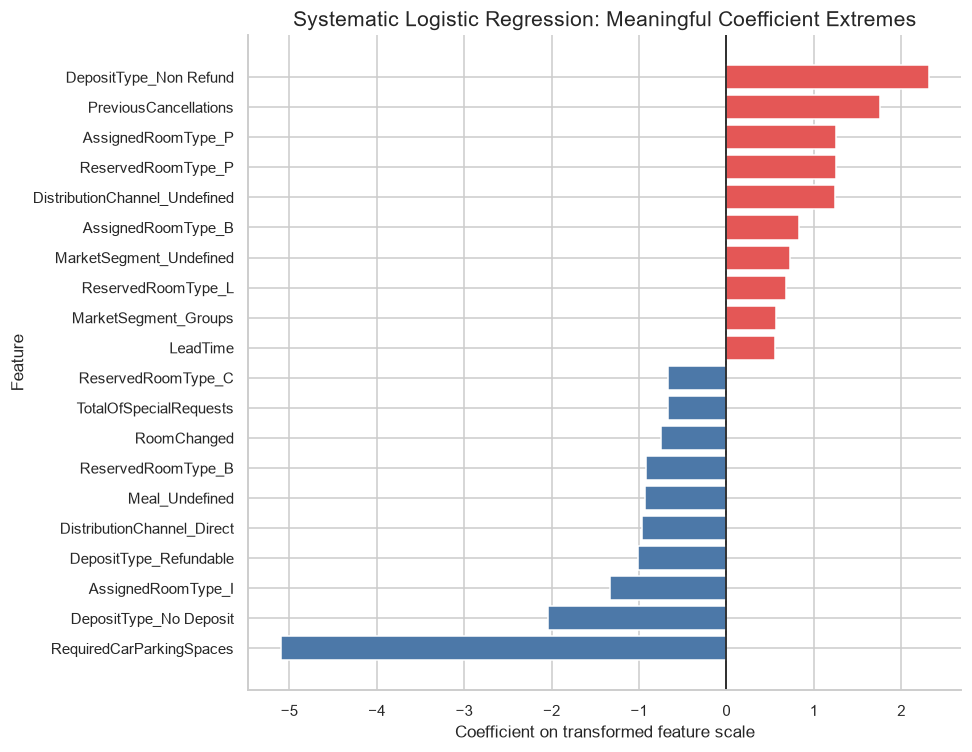

Saved figure: figures\14_logistic_coefficients.png


In [21]:
fitted_systematic = systematic_result['pipeline']
feature_names = fitted_systematic.named_steps['preprocessor'].get_feature_names_out()
coefficients = pd.Series(
    fitted_systematic.named_steps['model'].coef_[0], index=feature_names, name='coefficient'
).sort_values()
identifier_like_patterns = ['Agent_', 'Company_', 'Country_', 'HotelSourceFile_']
meaningful_coefficients = coefficients[~coefficients.index.to_series().apply(
    lambda name: any(pattern in name for pattern in identifier_like_patterns)
)]
coefficient_extremes = pd.concat([meaningful_coefficients.head(10),
                                  meaningful_coefficients.tail(10)]).sort_values()
clean_coefficient_labels = (coefficient_extremes.index.to_series()
                            .str.replace('numeric__', '', regex=False)
                            .str.replace('categorical__', '', regex=False))
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(clean_coefficient_labels, coefficient_extremes,
        color=np.where(coefficient_extremes < 0, '#4C78A8', '#E45756'))
plt.axvline(0, color='black', linewidth=1)
ax.set(title='Systematic Logistic Regression: Meaningful Coefficient Extremes',
       xlabel='Coefficient on transformed feature scale', ylabel='Feature')
save_and_show('14_logistic_coefficients.png')


### Interpretation
**TODO after execution:** Discuss only stable differences among sufficiently represented subgroups; disparities are diagnostic and do not establish unfairness without deployment context. Coefficients indicate conditional model associations on the transformed scale, not causal effects, and remain sensitive to encoding, correlation, frequency, and regularisation.

# 16. Limitations

Review and retain only limitations supported by the final analysis:

- The data are observational; associations do not establish causality.
- Unrecorded confounders may explain observed relationships.
- No unique booking identifier is available, limiting duplicate confirmation.
- Representativeness depends on the hotels, period, geography, and collection process documented by the source.
- Historical operational patterns may not transfer to a later or different deployment context.
- Fairness assessment is limited by available group variables and absent deployment context.
- The modelling exercise deliberately uses one simple interpretable algorithm and limited tuning.
- A random split may not represent temporal deployment; consider a time-based sensitivity analysis if the intended use predicts future bookings.

**TODO after execution:** Remove inapplicable items and add evidence-specific limitations.

# 17. Conclusion

Systematic profiling revealed several important data-quality and integrity issues in the Hotel Booking Demand dataset. Missingness was not limited to conventional `NaN` values: textual markers such as `"NULL"` were also present, demonstrating that standard null checks alone would underestimate missing data. A substantial number of rows also shared identical recorded feature values; however, because the dataset does not contain a unique booking identifier, these observations cannot be confidently classified as duplicate bookings and were therefore not removed solely on this basis.

The most consequential finding was **outcome leakage**. `ReservationStatus` was strongly aligned with `IsCanceled` because it records the eventual booking outcome, while `ReservationStatusDate` similarly contains information associated with the post-booking process. Although these variables provide extremely strong predictive signals, they would not constitute legitimate information for predicting cancellation before the outcome occurs. They were therefore excluded from the systematically prepared dataset.

This decision had the largest impact on model behaviour. The minimally processed Logistic Regression model achieved perfect evaluation scores, including an accuracy and ROC-AUC of 1.00. After systematic preparation and removal of leakage variables, performance decreased to approximately **0.84 accuracy and 0.92 ROC-AUC**. The staged ablation analysis showed that ordinary cleaning and invalid-value handling produced relatively little change, whereas leakage removal caused the major reduction in apparent predictive performance. Subsequent feature engineering produced only a small additional change.

This deterioration should not be interpreted as a failure of data preparation. Instead, the perfect performance of the minimal model was misleading because it relied on information that effectively revealed the target outcome. The systematically prepared model therefore provides a more credible estimate of genuine predictive performance, even though its numerical accuracy is lower. This illustrates the central data-centric insight of the analysis: **higher model performance does not necessarily imply better data or a more valid predictive system**.

The exploratory and subgroup analyses also identified differences in cancellation behaviour across several booking and customer groups. These patterns are useful for understanding the structure of the dataset, but they remain observational associations. They do not by themselves establish causal relationships or demonstrate unfair discrimination. Similarly, potentially duplicated observations cannot be definitively resolved without a unique booking identifier.

Overall, the analysis demonstrates that systematic data profiling and evidence-based preparation can materially change how machine-learning results should be interpreted. In this dataset, the most important contribution of data preparation was not an increase in predictive accuracy, but the identification and removal of misleading information that made the original model appear unrealistically strong. Further validation would require clearer information about when each feature becomes available during the booking process, unique booking identifiers, and additional evidence about the representativeness of the observed customer and booking groups.

# 18. Generative AI Declaration

Generative AI tools were used as supporting tools during the development of this project, primarily for code assistance, debugging, suggestions on data visualisation, and language refinement.

The overall analytical workflow, selection of investigation areas, data preparation decisions, model design, and interpretation of results were determined and evaluated by the group members. All code and AI-generated suggestions were reviewed before inclusion, and the notebook was executed and verified by the group using the actual dataset.

All reported findings and conclusions were derived from the empirical results produced in the notebook and were critically assessed by the group. Generative AI served only as an assistive tool; responsibility for the analysis, methodological decisions, interpretation, and final submission remains with the group members.